In [61]:
# Predicting Heart Disease
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score

In [62]:
data = pd.read_csv("train.csv")
df = data.copy()

In [63]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [64]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [65]:
df = df.drop("id",axis=1)

In [66]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [67]:
list_for_boxplot = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium']

In [77]:
df['Heart Disease'].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

<Axes: >

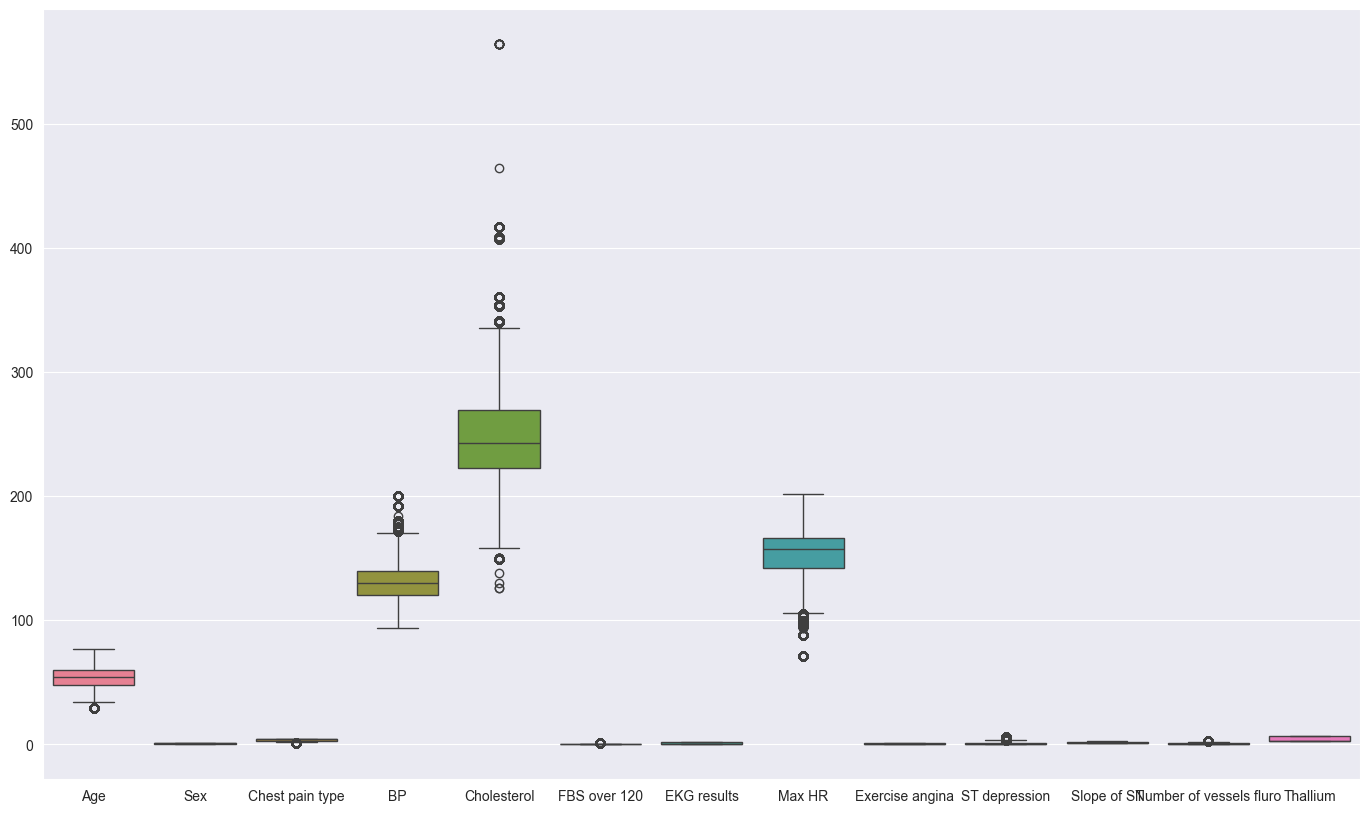

In [68]:
plt.figure(figsize = (17,10))
sns.boxplot(df[list_for_boxplot])

<Axes: ylabel='Age'>

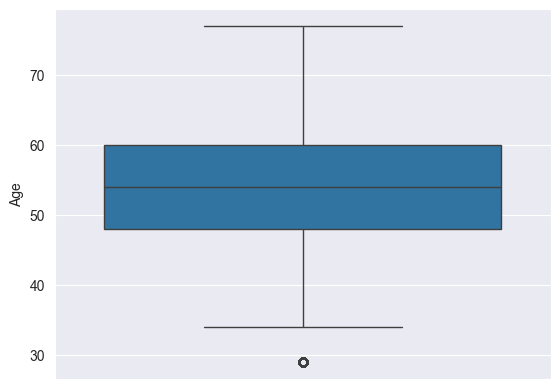

In [69]:
sns.boxplot(df["Age"])

In [70]:
df[df['Age'] < 30]

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
891,29,1,4,140,222,0,0,160,1,0.0,2,1,7,Presence
1165,29,0,2,140,233,1,0,172,0,0.8,2,0,3,Absence
1541,29,0,3,112,246,0,0,156,0,0.0,1,2,3,Absence
2879,29,0,2,120,204,0,0,168,0,0.0,1,0,3,Absence
3045,29,0,3,140,233,0,2,178,0,0.0,1,0,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627849,29,0,3,110,177,0,0,163,0,0.0,1,0,3,Absence
628668,29,0,4,130,250,0,0,174,0,0.0,1,0,3,Absence
628763,29,1,3,130,177,0,2,161,0,0.5,1,0,3,Absence
629108,29,1,3,130,233,0,2,150,0,0.0,1,0,3,Absence


In [71]:
df['Heart Disease'] = df['Heart Disease'].map({'Absence': 0, 'Presence': 1})

In [72]:
X = df.drop("Heart Disease",axis=1)
y = df["Heart Disease"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

ds_model = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_split = 2,
    min_samples_leaf = 1,
    criterion = 'gini',
    random_state = 42
)

ds_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [73]:
y_pred = ds_model.predict(X_test)

In [74]:
print("ROC-AUC Score: ", roc_auc_score(y_test, y_pred))

ROC-AUC Score:  0.8786886473708059


In [75]:
# Default value model: ROC-AUC Score:  0.8227754140784642
# Зміна гіперпараметрів(max_depth, min_samples_split, min_samples_leaf, criterion): ROC-AUC Score:  0.8786903193381899

In [88]:
test_data = pd.read_csv('test.csv')
X_test_final = test_data.drop(['id'], axis=1)

In [89]:
predictions = ds_model.predict(X_test_final)

#reverse_mapping = {0: 'Absence', 1: 'Presence'}
#final_labels = [reverse_mapping[pred] for pred in predictions]

In [93]:
submission = pd.DataFrame({
    'id': test_data['id'],
    'Heart Disease': predictions
})

submission.to_csv('my_submission.csv', index=False)